# Коллаборативная фильтрация

## Этап 1. Загрузка и подготовка данных

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, accuracy
from surprise import KNNBasic, KNNWithMeans, SVD, BaselineOnly, NormalPredictor
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV
from surprise.builtin_datasets import BUILTIN_DATASETS

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (9, 4)
pd.set_option('display.max_columns', 30)

In [2]:
data = Dataset.load_builtin('ml-100k', prompt=False)

ratings = pd.DataFrame(data.raw_ratings, columns=['userId', 'movieId', 'rating', 'timestamp'])
ratings['rating'] = ratings['rating'].astype(float)

print('Оценок:', len(ratings))
print('Пользователей:', ratings.userId.nunique(), '| фильмов:', ratings.movieId.nunique())
print('Шкала оценок:', ratings.rating.min(), '-', ratings.rating.max())
ratings.head()

Оценок: 100000
Пользователей: 943 | фильмов: 1682
Шкала оценок: 1.0 - 5.0


,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


In [3]:
data_dir = os.path.dirname(BUILTIN_DATASETS['ml-100k'].path)
GENRES = ['unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
          'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
          'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

items = pd.read_csv(f'{data_dir}/u.item', sep='|', encoding='latin-1', header=None,
                    names=['movieId', 'title', 'release', 'video', 'url'] + GENRES)
items['movieId'] = items['movieId'].astype(str)
items['genres'] = items[GENRES].apply(lambda r: '|'.join([g for g in GENRES if r[g] == 1]), axis=1)

title_of = items.set_index('movieId')['title']
genres_of = items.set_index('movieId')['genres']

print('Фильмов в справочнике:', len(items))
items[['movieId', 'title', 'genres']].head()

Фильмов в справочнике: 1682


,movieId,title,genres
0,1,Toy Story (1995),Animation|Children|Comedy
1,2,GoldenEye (1995),Action|Adventure|Thriller
2,3,Four Rooms (1995),Thriller
3,4,Get Shorty (1995),Action|Comedy|Drama
4,5,Copycat (1995),Crime|Drama|Thriller


## Этап 2. Исследовательский анализ данных (EDA)

,count,mean,std,min,25%,50%,75%,max
rating,100000.0,3.52986,1.125674,1.0,3.0,4.0,4.0,5.0


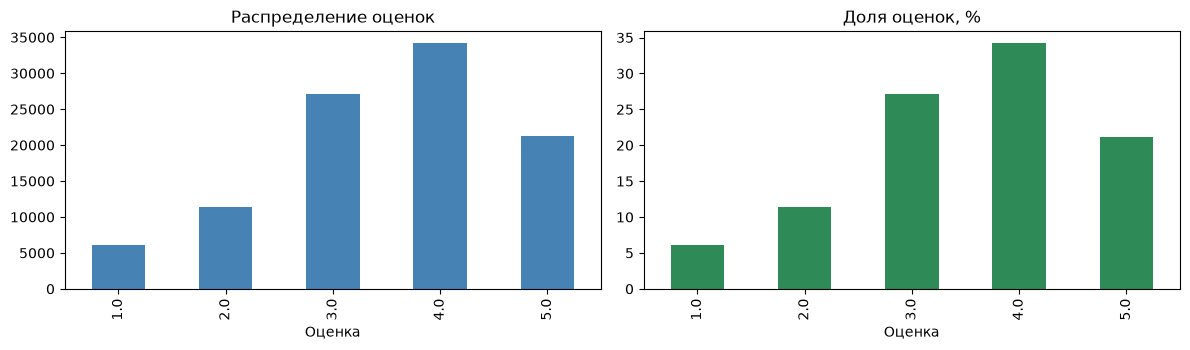

Средняя оценка: 3.53 | медиана: 4.0
Доля оценок 4 и 5: 55.4 %
RMSE «наивного» предсказания глобальным средним: 1.1257


In [4]:
display(ratings['rating'].describe().to_frame().T)

counts = ratings['rating'].value_counts().sort_index()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
counts.plot.bar(ax=ax[0], color='steelblue', title='Распределение оценок')
ax[0].set_xlabel('Оценка')
(counts / counts.sum() * 100).round(1).plot.bar(ax=ax[1], color='seagreen', title='Доля оценок, %')
ax[1].set_xlabel('Оценка')
plt.tight_layout()
plt.show()

print('Средняя оценка:', round(ratings.rating.mean(), 3), '| медиана:', ratings.rating.median())
print('Доля оценок 4 и 5:', round((ratings.rating >= 4).mean() * 100, 1), '%')

naive_rmse = np.sqrt(((ratings.rating - ratings.rating.mean()) ** 2).mean())
print(f'RMSE «наивного» предсказания глобальным средним: {naive_rmse:.4f}')

Оценки смещены вверх: люди чаще ставят оценку фильмам, которые сами выбрали смотреть. Предсказание одним глобальным средним даёт RMSE ≈ 1.12 - это верхняя планка, которую любая осмысленная модель обязана пробить.

Оценок на пользователя: min=20, median=65, mean=106.0, max=737
Оценок на фильм:        min=1, median=27, mean=59.5, max=583


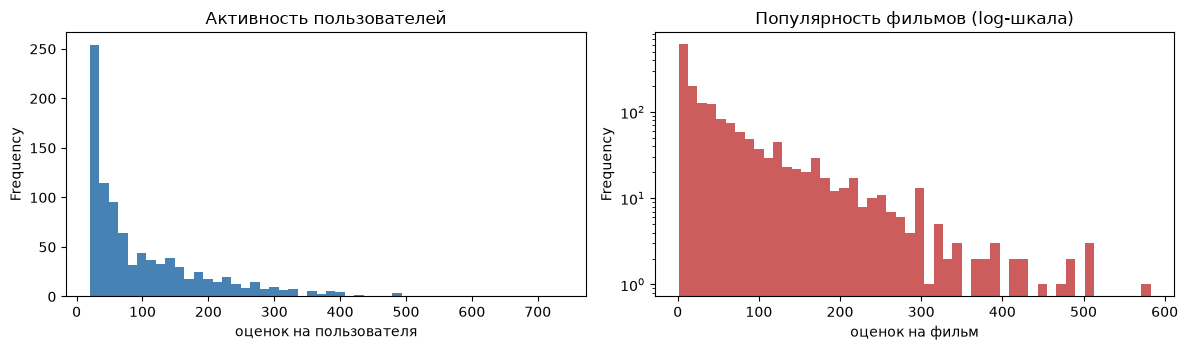

In [5]:
user_activity = ratings.groupby('userId').size()
movie_popularity = ratings.groupby('movieId').size()

print('Оценок на пользователя: min={}, median={}, mean={:.1f}, max={}'.format(
    user_activity.min(), int(user_activity.median()), user_activity.mean(), user_activity.max()))
print('Оценок на фильм:        min={}, median={}, mean={:.1f}, max={}'.format(
    movie_popularity.min(), int(movie_popularity.median()), movie_popularity.mean(), movie_popularity.max()))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
user_activity.plot.hist(bins=50, ax=ax[0], color='steelblue', title='Активность пользователей')
ax[0].set_xlabel('оценок на пользователя')
movie_popularity.plot.hist(bins=50, ax=ax[1], color='indianred', log=True,
                           title='Популярность фильмов (log-шкала)')
ax[1].set_xlabel('оценок на фильм')
plt.tight_layout()
plt.show()

,title,n_ratings,mean_rating
movieId,,,
50,Star Wars (1977),583,4.36
258,Contact (1997),509,3.80
100,Fargo (1996),508,4.16
181,Return of the Jedi (1983),507,4.01
294,Liar Liar (1997),485,3.16
286,"English Patient, The (1996)",481,3.66
288,Scream (1996),478,3.44
1,Toy Story (1995),452,3.88
300,Air Force One (1997),431,3.63


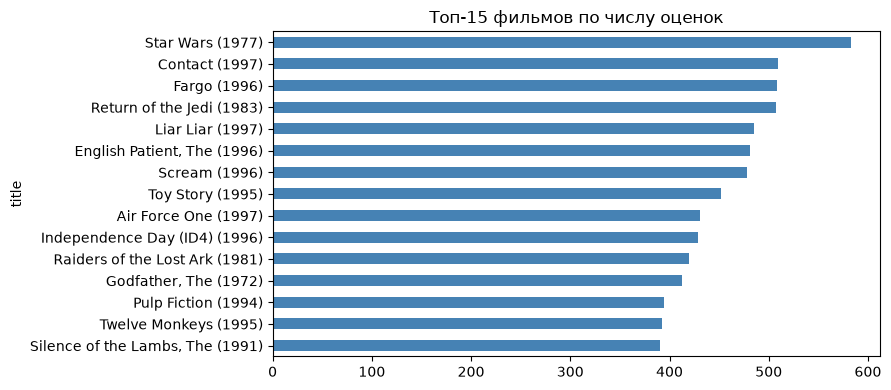

In [6]:
top = (ratings.groupby('movieId')
       .agg(n_ratings=('rating', 'size'), mean_rating=('rating', 'mean'))
       .sort_values('n_ratings', ascending=False)
       .head(15))
top.insert(0, 'title', title_of.reindex(top.index).values)
display(top.round(2))

top.set_index('title')['n_ratings'][::-1].plot.barh(color='steelblue',
                                                   title='Топ-15 фильмов по числу оценок')
plt.tight_layout()
plt.show()

### Разреженность матрицы «пользователь × фильм»

In [7]:
n_users = ratings.userId.nunique()
n_items = ratings.movieId.nunique()
n_cells = n_users * n_items
n_filled = len(ratings)
sparsity = 1 - n_filled / n_cells

print(f'Размер матрицы: {n_users} x {n_items} = {n_cells:,} ячеек'.replace(',', ' '))
print(f'Заполнено: {n_filled:,} оценок'.replace(',', ' '))
print(f'Плотность: {100 * n_filled / n_cells:.2f} %')
print(f'Разреженность: {100 * sparsity:.2f} %')

for thr in [5, 10, 20, 50]:
    print(f'Фильмов с числом оценок < {thr:3d}: {(movie_popularity < thr).sum():4d} '
          f'({100 * (movie_popularity < thr).mean():4.1f} %) | '
          f'пользователей с < {thr:3d} оценок: {(user_activity < thr).sum():3d} '
          f'({100 * (user_activity < thr).mean():4.1f} %)')

Размер матрицы: 943 x 1682 = 1 586 126 ячеек
Заполнено: 100 000 оценок
Плотность: 6.30 %
Разреженность: 93.70 %
Фильмов с числом оценок <   5:  333 (19.8 %) | пользователей с <   5 оценок:   0 ( 0.0 %)
Фильмов с числом оценок <  10:  530 (31.5 %) | пользователей с <  10 оценок:   0 ( 0.0 %)
Фильмов с числом оценок <  20:  743 (44.2 %) | пользователей с <  20 оценок:   0 ( 0.0 %)
Фильмов с числом оценок <  50: 1079 (64.1 %) | пользователей с <  50 оценок: 375 (39.8 %)


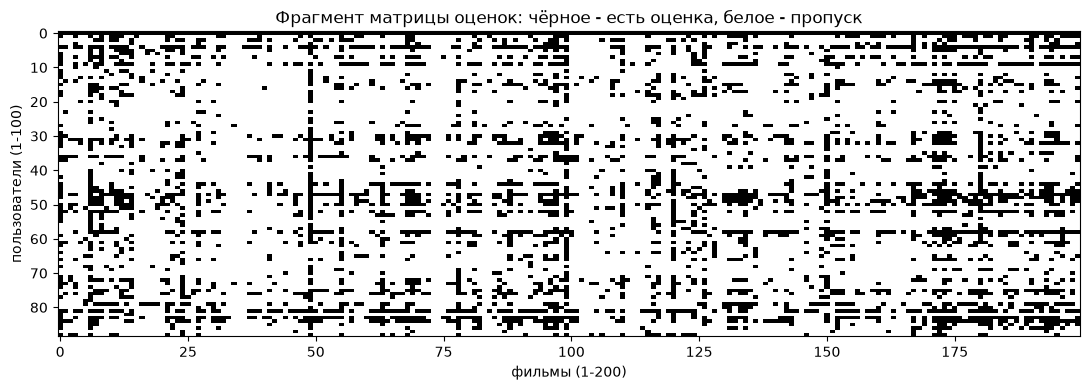

In [8]:
pivot = (ratings[ratings.userId.astype(int) <= 100]
         .assign(m=lambda d: d.movieId.astype(int))
         .query('m <= 200')
         .pivot_table(index='userId', columns='m', values='rating'))

plt.figure(figsize=(11, 4))
plt.imshow(pivot.notna().values, aspect='auto', cmap='Greys', interpolation='nearest')
plt.title('Фрагмент матрицы оценок: чёрное - есть оценка, белое - пропуск')
plt.xlabel('фильмы (1-200)')
plt.ylabel('пользователи (1-100)')
plt.tight_layout()
plt.show()

## Этап 3. Реализация моделей

In [9]:
sim_user = {'name': 'cosine', 'user_based': True}
sim_item = {'name': 'cosine', 'user_based': False}

models = {
    'User-based KNNBasic (cosine)':     KNNBasic(k=40, sim_options=sim_user, verbose=False),
    'Item-based KNNBasic (cosine)':     KNNBasic(k=40, sim_options=sim_item, verbose=False),
    'User-based KNNWithMeans (cosine)': KNNWithMeans(k=40, sim_options=sim_user, verbose=False),
    'Item-based KNNWithMeans (cosine)': KNNWithMeans(k=40, sim_options=sim_item, verbose=False),
    'SVD (матричная факторизация)':     SVD(random_state=RANDOM_STATE),
    'BaselineOnly (только смещения)':   BaselineOnly(verbose=False),
    'NormalPredictor (случайно)':       NormalPredictor(),
}

for name in models:
    print(name)

User-based KNNBasic (cosine)
Item-based KNNBasic (cosine)
User-based KNNWithMeans (cosine)
Item-based KNNWithMeans (cosine)
SVD (матричная факторизация)
BaselineOnly (только смещения)
NormalPredictor (случайно)


## Этап 4. Кросс-валидация и оценка качества

In [10]:
%%time
results = {}

for name, model in models.items():
    cv = cross_validate(model, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    results[name] = {
        'RMSE': np.mean(cv['test_rmse']),
        'RMSE_std': np.std(cv['test_rmse']),
        'MAE': np.mean(cv['test_mae']),
        'MAE_std': np.std(cv['test_mae']),
        'fit_time, s': np.mean(cv['fit_time']),
        'test_time, s': np.mean(cv['test_time']),
    }
    print(f'{name:36s} RMSE = {results[name]["RMSE"]:.4f} | MAE = {results[name]["MAE"]:.4f}')

User-based KNNBasic (cosine)         RMSE = 1.0171 | MAE = 0.8044
Item-based KNNBasic (cosine)         RMSE = 1.0275 | MAE = 0.8123
User-based KNNWithMeans (cosine)     RMSE = 0.9551 | MAE = 0.7544
Item-based KNNWithMeans (cosine)     RMSE = 0.9425 | MAE = 0.7408
SVD (матричная факторизация)         RMSE = 0.9361 | MAE = 0.7382
BaselineOnly (только смещения)       RMSE = 0.9436 | MAE = 0.7481
NormalPredictor (случайно)           RMSE = 1.5202 | MAE = 1.2202
CPU times: user 51 s, sys: 96.1 ms, total: 51.1 s
Wall time: 51.2 s


,RMSE,RMSE_std,MAE,MAE_std,"fit_time, s","test_time, s"
SVD (матричная факторизация),0.9361,0.0025,0.7382,0.0028,0.5560,0.0537
Item-based KNNWithMeans (cosine),0.9425,0.0045,0.7408,0.0043,0.4474,1.9271
BaselineOnly (только смещения),0.9436,0.0048,0.7481,0.0042,0.1271,0.0416
User-based KNNWithMeans (cosine),0.9551,0.0035,0.7544,0.0030,0.3108,1.6423
User-based KNNBasic (cosine),1.0171,0.0047,0.8044,0.0048,0.3510,1.7788
Item-based KNNBasic (cosine),1.0275,0.0040,0.8123,0.0041,0.4396,1.8343
NormalPredictor (случайно),1.5202,0.0086,1.2202,0.0057,0.0515,0.0521


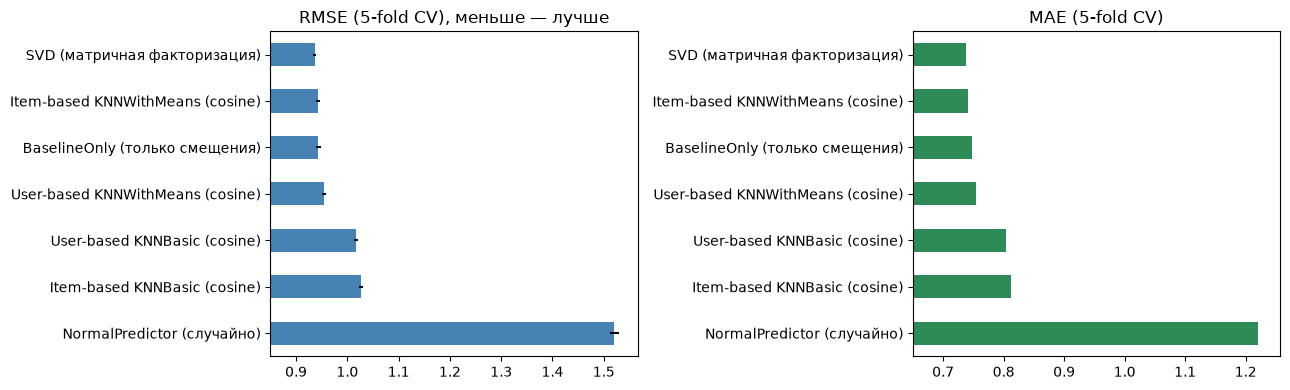

In [11]:
scores = pd.DataFrame(results).T.sort_values('RMSE')
display(scores.round(4))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
scores['RMSE'][::-1].plot.barh(ax=ax[0], color='steelblue', xerr=scores['RMSE_std'][::-1],
                               title='RMSE (5-fold CV), меньше — лучше')
ax[0].set_xlim(0.85, scores['RMSE'].max() * 1.03)
scores['MAE'][::-1].plot.barh(ax=ax[1], color='seagreen', title='MAE (5-fold CV)')
ax[1].set_xlim(0.65, scores['MAE'].max() * 1.03)
plt.tight_layout()
plt.show()

### Сравнение user-based и item-based

In [12]:
cv_user = cross_validate(KNNBasic(k=40, sim_options=sim_user, verbose=False), data,
                         measures=['RMSE', 'MAE'], cv=5, verbose=False)
cv_item = cross_validate(KNNBasic(k=40, sim_options=sim_item, verbose=False), data,
                         measures=['RMSE', 'MAE'], cv=5, verbose=False)

folds = pd.DataFrame({
    'User-based RMSE': cv_user['test_rmse'],
    'Item-based RMSE': cv_item['test_rmse'],
    'User-based MAE': cv_user['test_mae'],
    'Item-based MAE': cv_item['test_mae'],
}, index=[f'fold {i + 1}' for i in range(5)])
folds.loc['среднее'] = folds.mean()
display(folds.round(4))

diff = np.array(cv_item['test_rmse']) - np.array(cv_user['test_rmse'])
print(f'Разница RMSE (item - user) по фолдам: {np.round(diff, 4)}')
print(f'В среднем: {diff.mean():+.4f} - item-based '
      f'{"хуже" if diff.mean() > 0 else "лучше"} на всех фолдах: {bool(np.all(np.sign(diff) == np.sign(diff.mean())))}')

,User-based RMSE,Item-based RMSE,User-based MAE,Item-based MAE
fold 1,1.0111,1.0342,0.8029,0.8183
fold 2,1.0223,1.0253,0.8067,0.8129
fold 3,1.0198,1.0211,0.8053,0.8063
fold 4,1.0163,1.0296,0.8040,0.8137
fold 5,1.0138,1.0232,0.8010,0.8075
среднее,1.0167,1.0267,0.8040,0.8117


Разница RMSE (item - user) по фолдам: [0.023  0.0029 0.0013 0.0133 0.0094]
В среднем: +0.0100 - item-based хуже на всех фолдах: True


### Подбор гиперпараметров

In [13]:
%%time
param_grid = {
    'k': [20, 40, 60],
    'sim_options': {
        'name': ['cosine', 'msd', 'pearson_baseline'],
        'user_based': [True, False],
    },
    'verbose': [False],
}

gs = GridSearchCV(KNNWithMeans, param_grid, measures=['rmse', 'mae'], cv=3, joblib_verbose=0)
gs.fit(data)

print('Лучший RMSE:', round(gs.best_score['rmse'], 4))
print('Лучшие параметры:', gs.best_params['rmse'])

Лучший RMSE: 0.9341
Лучшие параметры: {'k': 40, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}, 'verbose': False}
CPU times: user 2min 33s, sys: 19 ms, total: 2min 33s
Wall time: 2min 33s


In [14]:
grid = pd.DataFrame(gs.cv_results)
grid['similarity'] = grid['param_sim_options'].apply(lambda d: d['name'])
grid['подход'] = grid['param_sim_options'].apply(lambda d: 'user-based' if d['user_based'] else 'item-based')
pivot_grid = grid.pivot_table(index=['подход', 'similarity'], columns='param_k',
                              values='mean_test_rmse').round(4)
display(pivot_grid)

param_k                          20      40      60
подход     similarity                              
item-based cosine            0.9633  0.9505  0.9477
           msd               0.9507  0.9420  0.9409
           pearson_baseline  0.9363  0.9341  0.9345
user-based cosine            0.9716  0.9623  0.9608
           msd               0.9644  0.9576  0.9569
           pearson_baseline  0.9505  0.9482  0.9484

In [15]:
best_params = gs.best_params['rmse']
tuned_name = ('Подобранная KNNWithMeans '
              f'({"user" if best_params["sim_options"]["user_based"] else "item"}-based, '
              f'{best_params["sim_options"]["name"]}, k={best_params["k"]})')

tuned = KNNWithMeans(k=best_params['k'], sim_options=best_params['sim_options'], verbose=False)
cv_tuned = cross_validate(tuned, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

results[tuned_name] = {
    'RMSE': np.mean(cv_tuned['test_rmse']),
    'RMSE_std': np.std(cv_tuned['test_rmse']),
    'MAE': np.mean(cv_tuned['test_mae']),
    'MAE_std': np.std(cv_tuned['test_mae']),
    'fit_time, s': np.mean(cv_tuned['fit_time']),
    'test_time, s': np.mean(cv_tuned['test_time']),
}

scores = pd.DataFrame(results).T.sort_values('RMSE')
print(tuned_name)
print(f'RMSE = {results[tuned_name]["RMSE"]:.4f} | MAE = {results[tuned_name]["MAE"]:.4f}')
display(scores[['RMSE', 'MAE']].round(4))

Подобранная KNNWithMeans (item-based, pearson_baseline, k=40)
RMSE = 0.9207 | MAE = 0.7203


,RMSE,MAE
"Подобранная KNNWithMeans (item-based, pearson_baseline, k=40)",0.9207,0.7203
SVD (матричная факторизация),0.9361,0.7382
Item-based KNNWithMeans (cosine),0.9425,0.7408
BaselineOnly (только смещения),0.9436,0.7481
User-based KNNWithMeans (cosine),0.9551,0.7544
User-based KNNBasic (cosine),1.0171,0.8044
Item-based KNNBasic (cosine),1.0275,0.8123
NormalPredictor (случайно),1.5202,1.2202


## Этап 5. Проверка «в полях»: рекомендации для случайного пользователя

In [16]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)

best_knn = KNNWithMeans(k=gs.best_params['rmse']['k'],
                        sim_options=gs.best_params['rmse']['sim_options'], verbose=False)
best_knn.fit(trainset)
preds = best_knn.test(testset)

print('Лучшая KNN-модель:', gs.best_params['rmse'])
print('RMSE на отложенной выборке:', round(accuracy.rmse(preds, verbose=False), 4))
print('MAE  на отложенной выборке:', round(accuracy.mae(preds, verbose=False), 4))

Лучшая KNN-модель: {'k': 40, 'sim_options': {'name': 'pearson_baseline', 'user_based': False}, 'verbose': False}
RMSE на отложенной выборке: 0.9204
MAE  на отложенной выборке: 0.72


In [17]:
def recommend(uid, model, trainset, n=10, min_ratings=0):

    inner_uid = trainset.to_inner_uid(uid)
    seen = {trainset.to_raw_iid(i) for i, _ in trainset.ur[inner_uid]}
    candidates = [iid for iid in ratings.movieId.unique()
                  if iid not in seen and movie_popularity.get(iid, 0) >= min_ratings]

    est = [(iid, model.predict(uid, iid).est) for iid in candidates]
    top = sorted(est, key=lambda x: -x[1])[:n]

    return pd.DataFrame({
        'title': [title_of.get(i, i) for i, _ in top],
        'genres': [genres_of.get(i, '') for i, _ in top],
        'predicted_rating': [round(e, 2) for _, e in top],
        'n_ratings': [int(movie_popularity.get(i, 0)) for i, _ in top],
    })


uid = str(np.random.RandomState(RANDOM_STATE).choice(ratings.userId.unique()))
user_ratings = ratings[ratings.userId == uid]
print(f'Случайный пользователь: {uid} | оценок: {len(user_ratings)} | '
      f'средняя оценка: {user_ratings.rating.mean():.2f}')

liked = (user_ratings.sort_values('rating', ascending=False).head(10).assign(
    title=lambda d: title_of.reindex(d.movieId).values,
    genres=lambda d: genres_of.reindex(d.movieId).values))
print('\nЛюбимые фильмы пользователя (топ-10 по оценке):')
display(liked[['title', 'genres', 'rating']].reset_index(drop=True))

Случайный пользователь: 85 | оценок: 288 | средняя оценка: 3.54

Любимые фильмы пользователя (топ-10 по оценке):


,title,genres,rating
0,Manhattan (1979),Comedy|Drama|Romance,5.0
1,Annie Hall (1977),Comedy|Romance,5.0
2,Unforgiven (1992),Western,5.0
3,Priest (1994),Drama,5.0
4,"Godfather: Part II, The (1974)",Action|Crime|Drama,5.0
5,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi|War,5.0
6,Harold and Maude (1971),Comedy,5.0
7,Being There (1979),Comedy,5.0
8,"Boot, Das (1981)",Action|Drama|War,5.0
9,Citizen Kane (1941),Drama,5.0


In [18]:
recs = recommend(uid, best_knn, trainset, n=10)
print(f'Топ-10 рекомендаций для пользователя {uid} (без фильтров):')
display(recs)

Топ-10 рекомендаций для пользователя 85 (без фильтров):


,title,genres,predicted_rating,n_ratings
0,Santa with Muscles (1996),Comedy,5.00,2
1,"Great Day in Harlem, A (1994)",Documentary,5.00,1
2,Aiqing wansui (1994),Drama,5.00,1
3,Someone Else's America (1995),Drama,5.00,1
4,Entertaining Angels: The Dorothy Day Story (1996),Drama,5.00,1
5,They Made Me a Criminal (1939),Crime|Drama,5.00,1
6,Marlene Dietrich: Shadow and Light (1996),Documentary,5.00,1
7,"Saint of Fort Washington, The (1993)",Drama,4.81,2
8,Star Kid (1997),Adventure|Children|Fantasy|Sci-Fi,4.72,3
9,Casablanca (1942),Drama|Romance|War,4.57,243


Видно типичную болезнь KNN на разреженных данных: наверх выдачи попадают фильмы с одной-двумя оценками - достаточно пары «соседей» с пятёрками, чтобы предсказание упёрлось в максимум. Рекомендовать такое пользователю бессмысленно, поэтому добавим порог по числу оценок.

In [19]:
recs_filtered = recommend(uid, best_knn, trainset, n=10, min_ratings=50)
print(f'Топ-10 рекомендаций для пользователя {uid} (только фильмы с >= 50 оценками):')
display(recs_filtered)

Топ-10 рекомендаций для пользователя 85 (только фильмы с >= 50 оценками):


,title,genres,predicted_rating,n_ratings
0,Casablanca (1942),Drama|Romance|War,4.57,243
1,"Close Shave, A (1995)",Animation|Comedy|Thriller,4.47,112
2,12 Angry Men (1957),Drama,4.39,125
3,Ran (1985),Drama|War,4.33,70
4,Secrets & Lies (1996),Drama,4.30,162
5,One Flew Over the Cuckoo's Nest (1975),Drama,4.26,264
6,Rear Window (1954),Mystery|Thriller,4.24,209
7,"Wrong Trousers, The (1993)",Animation|Comedy,4.24,118
8,Wallace & Gromit: The Best of Aardman Animatio...,Animation,4.23,67
9,"Usual Suspects, The (1995)",Crime|Thriller,4.22,267


In [20]:
def genre_share(genres_series):
    s = genres_series.str.get_dummies('|').mean().sort_values(ascending=False)
    return (s * 100).round(1)

user_top_genres = genre_share(genres_of.reindex(user_ratings[user_ratings.rating >= 4].movieId).dropna())
rec_genres = genre_share(recs_filtered['genres'])

compare = pd.DataFrame({
    'доля в фильмах с оценкой >= 4, %': user_top_genres,
    'доля в рекомендациях, %': rec_genres,
}).fillna(0).sort_values('доля в рекомендациях, %', ascending=False).head(8)
display(compare)

print('Средняя популярность рекомендаций без фильтра:', int(recs['n_ratings'].mean()), 'оценок')
print('Средняя популярность рекомендаций с фильтром:', int(recs_filtered['n_ratings'].mean()), 'оценок')
print('В среднем по каталогу:', int(movie_popularity.mean()), 'оценок')

,"доля в фильмах с оценкой >= 4, %","доля в рекомендациях, %"
Drama,55.1,50.0
Animation,3.2,30.0
Thriller,7.7,30.0
Comedy,28.8,20.0
War,14.7,20.0
Romance,21.8,10.0
Mystery,5.1,10.0
Crime,5.1,10.0


Средняя популярность рекомендаций без фильтра: 25 оценок
Средняя популярность рекомендаций с фильтром: 163 оценок
В среднем по каталогу: 59 оценок


## Итоговая таблица

In [21]:
final = scores[['RMSE', 'MAE', 'fit_time, s', 'test_time, s']].copy()
final['Δ RMSE к лучшей'] = (final['RMSE'] - final['RMSE'].min()).round(4)
display(final.round(4))

print('Лучшая модель по RMSE:', final['RMSE'].idxmin(), '-', round(final['RMSE'].min(), 4))
print('Лучшая из требуемых в задании (KNNBasic user/item):',
      final.loc[['User-based KNNBasic (cosine)', 'Item-based KNNBasic (cosine)'], 'RMSE'].idxmin())

,RMSE,MAE,"fit_time, s","test_time, s",Δ RMSE к лучшей
"Подобранная KNNWithMeans (item-based, pearson_baseline, k=40)",0.9207,0.7203,0.6297,1.9092,0.0000
SVD (матричная факторизация),0.9361,0.7382,0.5560,0.0537,0.0155
Item-based KNNWithMeans (cosine),0.9425,0.7408,0.4474,1.9271,0.0219
BaselineOnly (только смещения),0.9436,0.7481,0.1271,0.0416,0.0230
User-based KNNWithMeans (cosine),0.9551,0.7544,0.3108,1.6423,0.0344
User-based KNNBasic (cosine),1.0171,0.8044,0.3510,1.7788,0.0964
Item-based KNNBasic (cosine),1.0275,0.8123,0.4396,1.8343,0.1068
NormalPredictor (случайно),1.5202,1.2202,0.0515,0.0521,0.5995


Лучшая модель по RMSE: Подобранная KNNWithMeans (item-based, pearson_baseline, k=40) - 0.9207
Лучшая из требуемых в задании (KNNBasic user/item): User-based KNNBasic (cosine)


## Выводы
**Разреженность.** Матрица «пользователь × фильм» - 943 × 1 682 = 1 586 126 ячеек, заполнено 100 000, то есть плотность **6.30 %**, разреженность **93.70 %**. Распределение сильно несимметрично: у каждого пользователя минимум 20 оценок (медиана 65), а вот у фильмов медиана всего 27, и у 44 % фильмов меньше 20 оценок. Отсюда два следствия: 
(а) матрицу нужно хранить в разреженном виде
(б) сходства для непопулярных фильмов считаются по 1-2 общим пользователям и потому шумные - это главный источник ошибки KNN.

**User-based против item-based.**
`KNNBasic` (косинус, k = 40): **user-based точнее** - RMSE 1.0171 против 1.0275 у item-based, причём разница воспроизводится на всех 5 фолдах (item-based хуже в каждом)
`KNNWithMeans` (косинус, k = 40): картина переворачивается - **item-based точнее**, RMSE 0.9425 против 0.9551
после подбора параметров лучшая KNN-конфигурация тоже item-based:
`pearson_baseline`, k = 40. По сетке item-based выигрывает у user-based при любой мере сходства и любом k.

Сырые косинусные сходства между фильмами сильно портит разброс «строгости»
пользователей, и `KNNBasic` от этого страдает. Как только вычитаются средние (`KNNWithMeans`)
или используется baseline-скорректированная корреляция (`pearson_baseline`), item-based
раскрывается: у фильма «характер» оценок стабильнее, чем у человека, а профилей-соседей
в среднем достаточно.

**Учёт средних важнее выбора подхода.** Переход `KNNBasic - KNNWithMeans` улучшает RMSE на 0.062 (user-based) и 0.085 (item-based), тогда как разница между user- и item-based - всего 0.010–0.013. То есть, основная часть ошибки `KNNBasic` - не «нашли не тех соседей», а несовпадение шкал: один пользователь ставит 3 там, где другой ставит 5

**KPI и классификация моделей.** За порог возьмём `BaselineOnly` - модель вообще без «коллаборативности», только смещения пользователя и фильма (RMSE 0.9436, MAE 0.7481): 
**эффективные** - подобранная `KNNWithMeans` (item-based, `pearson_baseline`, k = 40) и `SVD`: 
обе бьют порог, причём `SVD` предсказывает на порядок быстрее, так как не хранит матрицу сходств n × n
**пограничные** - `KNNWithMeans` с косинусом: item-based едва обходит порог (0.9425), user-based уже уступает ему (0.9551);
**неэффективные** - `KNNBasic` в любом варианте (≈ 1.02, хуже порога на 0.08) и `NormalPredictor` (1.52). Вывод для практики: голый KNN без нормировки на средние проигрывает даже тривиальной baseline-модели, использовать его нет смысла

**Рекомендации «в полях».** Пользователь 85 любит драмы и классику, среди его пятёрок «Annie Hall», «Godfather: Part II», «Citizen Kane», «Dr. Strangelove». Без фильтров модель выдала список из фильмов с 1-2 оценками («Santa with Muscles», «Aiqing wansui») - это чистый артефакт разреженности: пара соседей с пятёрками задирает прогноз до максимума. После фильтра по числу оценок (≥ 50) выдача становится осмысленной и попадает в жанровый профиль пользователя: доля драм в рекомендациях близка к доле драм среди его высоких оценок. Практический вывод: одной точности предсказания мало, поверх модели нужен фильтр по популярности (или сглаживание прогноза числом оценок).